In [1]:

!pip install pandas numpy matplotlib openpyxl lxml html5lib beautifulsoup4 --quiet


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2010&UniDbQuery.To=05.05.2026&UniDbQuery.P1=0"


response = requests.get(url)
response.encoding = 'utf-8'

print(f"Статус ответа: {response.status_code}")
print(f"Длина HTML: {len(response.text)} символов")
print("\nСтраница загружена!")

Статус ответа: 200
Длина HTML: 584375 символов

Страница загружена!


In [3]:

tables = pd.read_html(url)
df_raw = tables[0].copy()

print("=" * 100)
print("ПОЛНАЯ ТАБЛИЦА С САЙТА ЦБ")
print("=" * 100)
print(f"\nВсего строк: {len(df_raw)}")
print(f"Всего колонок: {len(df_raw.columns)}")
print(f"\nНазвания всех колонок: {df_raw.columns.tolist()}")
print("\n" + "=" * 100)
print("ПЕРВЫЕ 10 СТРОК ТАБЛИЦЫ:")
print("=" * 100)


df_raw.head(10)

ПОЛНАЯ ТАБЛИЦА С САЙТА ЦБ

Всего строк: 2541
Всего колонок: 7

Названия всех колонок: ['Тип аукциона', 'Срок, дни', 'Дата', 'Время аукциона', 'Общий объем заключенных сделок, млн руб.', 'Средневзвешенная ставка, % годовых', 'Код расчета']

ПЕРВЫЕ 10 СТРОК ТАБЛИЦЫ:


,Тип аукциона,"Срок, дни",Дата,Время аукциона,"Общий объем заключенных сделок, млн руб.","Средневзвешенная ставка, % годовых",Код расчета
0,Репо,7,05.05.2026,13:28,"4 130 000,0",145141,S1
1,Репо,7,28.04.2026,13:32,"4 590 000,0",145494,S1
2,Репо,7,21.04.2026,13:28,"4 480 000,0",150114,S1
3,Репо,7,14.04.2026,13:30,"4 330 000,0",150130,S1
4,Репо,1,14.04.2026,11:31,"310 000,0",150015,S0
5,Репо,7,07.04.2026,13:32,"4 610 000,0",150151,S1
6,Репо,7,31.03.2026,13:32,"4 220 000,0",150319,S1
7,Репо,7,24.03.2026,13:35,"4 090 000,0",150471,S1
8,Репо,7,17.03.2026,13:36,"4 180 000,0",155082,S1
9,Репо,7,10.03.2026,13:36,"3 660 000,0",155144,S1


In [4]:
# Читаем таблицу
tables = pd.read_html(url)
df_raw = tables[0].copy()

print("=" * 100)
print("ПОСЛЕДНИЕ 10 СТРОК ТАБЛИЦЫ С САЙТА ЦБ")
print("=" * 100)
print(f"\nВсего строк: {len(df_raw)}")
print(f"Колонки: {df_raw.columns.tolist()}")
print("\n" + "=" * 100)


df_raw.tail(10)

ПОСЛЕДНИЕ 10 СТРОК ТАБЛИЦЫ С САЙТА ЦБ

Всего строк: 2541
Колонки: ['Тип аукциона', 'Срок, дни', 'Дата', 'Время аукциона', 'Общий объем заключенных сделок, млн руб.', 'Средневзвешенная ставка, % годовых', 'Код расчета']



,Тип аукциона,"Срок, дни",Дата,Время аукциона,"Общий объем заключенных сделок, млн руб.","Средневзвешенная ставка, % годовых",Код расчета
2531,Репо,1,14.01.2010,16:00,00,00000,S0
2532,Репо,1,14.01.2010,11:30,"9 679,1",60900,S0
2533,Репо,1,13.01.2010,16:00,00,00000,S0
2534,Репо,1,13.01.2010,11:30,"15 577,2",60700,S0
2535,Репо,1,12.01.2010,16:00,"1 231,4",63600,S0
2536,Репо,7,12.01.2010,13:45,"78 127,6",60800,S1
2537,Репо,1,12.01.2010,11:30,"33 170,2",60600,S0
2538,Репо,1,11.01.2010,16:00,5828,60200,S0
2539,Репо,364,11.01.2010,13:30,00,00000,S2
2540,Репо,1,11.01.2010,11:30,"43 187,4",60700,S0


In [5]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import time

def parse_auction_for_date(date_str):
    """
    Парсит данные аукциона для конкретной даты
    Возвращает словарь с данными
    """
    url = f"https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"

    try:
        tables = pd.read_html(url)
        if tables and len(tables) > 0:
            df = tables[0]

            result = {'Дата': date_str}
            for _, row in df.iterrows():
                key = row.iloc[0]
                value = row.iloc[1]


                key = key.replace('репо', '').strip()


                if 'спрос' in key.lower():
                    result['Спрос'] = float(str(value).replace(' ', '').replace(',', '.'))
                elif 'общий объем заключенных сделок' in key.lower():
                    result['Размещение'] = float(str(value).replace(' ', '').replace(',', '.'))
                elif 'ставка отсечения' in key.lower():
                    result['Ставка_отсечения'] = float(value) / 10000  # Делим на 10000
                elif 'средневзвешенная ставка' in key.lower() and 'лимита' not in key.lower():
                    result['Средневзвешенная_ставка'] = float(value) / 10000
                elif 'срок' in key.lower():
                    result['Срок'] = int(value)

            return result
    except Exception as e:
        print(f"  Ошибка для {date_str}: {e}")

    return None


test_date = "05.05.2026"
print(f"Тестируем парсинг для {test_date}...")
test_result = parse_auction_for_date(test_date)

if test_result:
    print("\nРезультат парсинга:")
    for key, value in test_result.items():
        print(f"  {key}: {value}")
else:
    print("Не удалось распарсить")

Тестируем парсинг для 05.05.2026...

Результат парсинга:
  Дата: 05.05.2026
  Спрос: 5427593.6
  Размещение: 4130000.0
  Ставка_отсечения: 14.5014
  Средневзвешенная_ставка: 14.5141
  Срок: 7


In [6]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import time
import re

def clean_number(value):

    if value == '—' or value == '-' or value == '':
        return None
    try:

        cleaned = str(value).replace(' ', '').replace(',', '.')
        return float(cleaned)
    except:
        return None

def parse_auction_for_date(date_str):

    url = f"https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"

    try:
        tables = pd.read_html(url)
        if not tables or len(tables) == 0:
            return None

        df = tables[0]
        if df.shape[1] < 2:
            return None

        result = {'Дата': date_str}

        for _, row in df.iterrows():
            key = str(row.iloc[0]).strip()
            value = row.iloc[1] if len(row) > 1 else None


            if value == '—' or value == '-' or pd.isna(value):
                continue


            key = key.replace('репо', '').strip()
            key = key.replace('России', '').strip()


            if 'спрос' in key.lower():
                result['Спрос'] = clean_number(value)
            elif 'общий объем заключенных сделок' in key.lower():
                result['Размещение'] = clean_number(value)
            elif 'ставка отсечения' in key.lower():
                val = clean_number(value)
                if val:
                    result['Ставка_отсечения'] = val / 10000
            elif 'средневзвешенная ставка' in key.lower() and 'лимита' not in key.lower():
                val = clean_number(value)
                if val:
                    result['Средневзвешенная_ставка'] = val / 10000
            elif 'срок' in key.lower() and 'дни' in key.lower():
                result['Срок'] = int(value) if value else None


        if len(result) > 1:
            return result
        return None

    except Exception as e:

        return None

test_dates = ["05.05.2026", "28.04.2026", "21.04.2026"]

print("Тестируем парсинг на последних датах:")
print("=" * 60)

for date_str in test_dates:
    print(f"\n{date_str}...")
    result = parse_auction_for_date(date_str)
    if result:
        print(f"   Срок: {result.get('Срок', '?')} дн")
        print(f"   Спрос: {result.get('Спрос', 0):,.0f} млн руб")
        print(f"   Размещение: {result.get('Размещение', 0):,.0f} млн руб")
        print(f"   Ставка: {result.get('Средневзвешенная_ставка', 0)}%")
    else:
        print("   Нет данных")

Тестируем парсинг на последних датах:

05.05.2026...
   Срок: 7 дн
   Спрос: 5,427,594 млн руб
   Размещение: 4,130,000 млн руб
   Ставка: 14.5141%

28.04.2026...
   Срок: 7 дн
   Спрос: 6,937,778 млн руб
   Размещение: 4,590,000 млн руб
   Ставка: 14.5494%

21.04.2026...
   Срок: 7 дн
   Спрос: 5,175,118 млн руб
   Размещение: 4,480,000 млн руб
   Ставка: 15.0114%


In [7]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import time

def check_auction_exists(date_obj):
    """
    Проверяет, есть ли данные по аукциону на конкретную дату
    """
    date_str = date_obj.strftime('%d.%m.%Y')
    url = f"https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"

    try:
        tables = pd.read_html(url)
        if not tables:
            return False

        df = tables[0]

        if len(df) > 5 and 'спрос' in str(df.iloc[:, 0].values).lower():
            return True
        return False
    except:
        return False

def get_auction_data(date_obj):
    """
    Собирает данные по аукциону, если они есть
    """
    date_str = date_obj.strftime('%d.%m.%Y')
    url = f"https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"

    try:
        tables = pd.read_html(url)
        if not tables:
            return None

        df = tables[0]
        if df.shape[1] < 2:
            return None

        result = {'Дата': date_str}

        for _, row in df.iterrows():
            key = str(row.iloc[0]).strip()
            value = row.iloc[1] if len(row) > 1 else None

            if value == '—' or value == '-' or pd.isna(value):
                continue


            if 'спрос' in key.lower():
                val_str = str(value).replace(' ', '').replace(',', '.')
                try:
                    result['Спрос'] = float(val_str)
                except:
                    pass

            elif 'общий объем заключенных сделок' in key.lower():
                val_str = str(value).replace(' ', '').replace(',', '.')
                try:
                    result['Размещение'] = float(val_str)
                except:
                    pass

            elif 'ставка отсечения' in key.lower():
                try:
                    result['Ставка_отсечения'] = float(value) / 10000
                except:
                    pass

            elif 'средневзвешенная ставка' in key.lower() and 'лимита' not in key.lower():
                try:
                    result['Средневзвешенная_ставка'] = float(value) / 10000
                except:
                    pass

            elif 'срок' in key.lower() and 'дни' in key.lower():
                try:
                    result['Срок'] = int(value)
                except:
                    pass


        if 'Спрос' in result and result.get('Срок') == 7:
            return result
        return None

    except Exception as e:
        return None


print("=" * 60)
print("📊 СБОР РЕАЛЬНЫХ ДАННЫХ ПО АУКЦИОНАМ")
print("=" * 60)


end_date = datetime(2026, 5, 5)
start_date = end_date - timedelta(days=90)

all_dates = []
current = start_date
while current <= end_date:
    all_dates.append(current)
    current += timedelta(days=1)

print(f"Проверяем даты с {start_date.strftime('%d.%m.%Y')} по {end_date.strftime('%d.%m.%Y')}")
print(f"Всего дней: {len(all_dates)}")
print()

print("🔍 Поиск аукционов с данными...")
print("-" * 60)

auction_data = []
checked = 0

for date_obj in all_dates:
    date_str = date_obj.strftime('%d.%m.%Y')


    if check_auction_exists(date_obj):
        print(f" {date_str}: данные есть, собираем...", end=" ")
        data = get_auction_data(date_obj)
        if data:
            auction_data.append(data)
            print(f"Срок={data['Срок']}д, Спрос={data['Спрос']:,.0f}")
        else:
            print("не удалось собрать")
    else:

        pass

    checked += 1
    if checked % 30 == 0:
        print(f"   ...проверено {checked} из {len(all_dates)} дней")

print("-" * 60)
print(f"\n Найдено аукционов с данными: {len(auction_data)}")

if auction_data:
    df_auctions = pd.DataFrame(auction_data)

    # Оставляем только 7-дневные
    df_7d = df_auctions[df_auctions['Срок'] == 7].copy()

    print(f"Из них 7-дневных: {len(df_7d)}")
    print("\n" + "=" * 60)
    print("ТЕСТОВЫЕ ДАННЫЕ (последние 10):")
    print("=" * 60)


    display(df_7d.tail(10))


    if len(df_7d) > 0:
        df_7d['Cover_ratio'] = df_7d['Спрос'] / df_7d['Размещение']

        print("\n С COVER RATIO:")
        display(df_7d[['Дата', 'Срок', 'Спрос', 'Размещение', 'Cover_ratio', 'Средневзвешенная_ставка']].tail(10))

        # Проверяем сигналы стресса
        stress = df_7d[df_7d['Cover_ratio'] > 2.0]
        if len(stress) > 0:
            print(f"\n Найдено {len(stress)} аукционов с переспросом (Cover > 2.0):")
            display(stress[['Дата', 'Cover_ratio', 'Средневзвешенная_ставка']])
        else:
            print("\nПереспроса нет (Cover ratio ≤ 2.0)")
else:
    print("Данные не найдены")

📊 СБОР РЕАЛЬНЫХ ДАННЫХ ПО АУКЦИОНАМ
Проверяем даты с 04.02.2026 по 05.05.2026
Всего дней: 91

🔍 Поиск аукционов с данными...
------------------------------------------------------------
 10.02.2026: данные есть, собираем... Срок=7д, Спрос=3,740,225
 17.02.2026: данные есть, собираем... Срок=7д, Спрос=3,862,379
 24.02.2026: данные есть, собираем... Срок=7д, Спрос=4,518,629
 03.03.2026: данные есть, собираем... Срок=7д, Спрос=4,181,973
   ...проверено 30 из 91 дней
 10.03.2026: данные есть, собираем... Срок=7д, Спрос=5,019,857
 17.03.2026: данные есть, собираем... Срок=7д, Спрос=4,753,071
 24.03.2026: данные есть, собираем... Срок=7д, Спрос=6,461,383
 31.03.2026: данные есть, собираем... Срок=7д, Спрос=5,896,230
   ...проверено 60 из 91 дней
 07.04.2026: данные есть, собираем... Срок=7д, Спрос=6,198,664
 14.04.2026: данные есть, собираем... Срок=7д, Спрос=5,225,511
 21.04.2026: данные есть, собираем... Срок=7д, Спрос=5,175,118
 28.04.2026: данные есть, собираем... Срок=7д, Спрос=6,937,77

,Дата,Спрос,Размещение,Ставка_отсечения,Средневзвешенная_ставка,Срок
3,03.03.2026,4181973.3,2990000.0,15.5015,15.5207,7
4,10.03.2026,5019856.8,3660000.0,15.5000,15.5144,7
5,17.03.2026,4753070.7,4180000.0,15.5000,15.5082,7
6,24.03.2026,6461382.9,4090000.0,15.0015,15.0471,7
7,31.03.2026,5896230.3,4220000.0,15.0015,15.0319,7
8,07.04.2026,6198663.5,4610000.0,15.0015,15.0151,7
9,14.04.2026,5225511.4,4330000.0,15.0000,15.0130,7
10,21.04.2026,5175118.1,4480000.0,15.0000,15.0114,7
11,28.04.2026,6937777.9,4590000.0,14.5014,14.5494,7
12,05.05.2026,5427593.6,4130000.0,14.5014,14.5141,7



 С COVER RATIO:


,Дата,Срок,Спрос,Размещение,Cover_ratio,Средневзвешенная_ставка
3,03.03.2026,7,4181973.3,2990000.0,1.398653,15.5207
4,10.03.2026,7,5019856.8,3660000.0,1.371546,15.5144
5,17.03.2026,7,4753070.7,4180000.0,1.137098,15.5082
6,24.03.2026,7,6461382.9,4090000.0,1.579800,15.0471
7,31.03.2026,7,5896230.3,4220000.0,1.397211,15.0319
8,07.04.2026,7,6198663.5,4610000.0,1.344612,15.0151
9,14.04.2026,7,5225511.4,4330000.0,1.206816,15.0130
10,21.04.2026,7,5175118.1,4480000.0,1.155160,15.0114
11,28.04.2026,7,6937777.9,4590000.0,1.511498,14.5494
12,05.05.2026,7,5427593.6,4130000.0,1.314187,14.5141



Переспроса нет (Cover ratio ≤ 2.0)


In [8]:
import pandas as pd
import requests
from datetime import datetime, timedelta
import time

def get_auction_data(date_obj):

    date_str = date_obj.strftime('%d.%m.%Y')
    url = f"https://www.cbr.ru/hd_base/repo/?UniDbQuery.Posted=True&UniDbQuery.From={date_str}&UniDbQuery.To={date_str}&UniDbQuery.P1=0"

    try:
        tables = pd.read_html(url)
        if not tables or len(tables) == 0:
            return None

        df = tables[0]
        if df.shape[1] < 2:
            return None

        result = {'Дата': date_str}

        for _, row in df.iterrows():
            key = str(row.iloc[0]).strip()
            value = row.iloc[1] if len(row) > 1 else None

            if value == '—' or value == '-' or pd.isna(value):
                continue

            if 'спрос' in key.lower():
                try:
                    val_str = str(value).replace(' ', '').replace(',', '.')
                    result['Спрос'] = float(val_str)
                except:
                    pass

            elif 'общий объем заключенных сделок' in key.lower():
                try:
                    val_str = str(value).replace(' ', '').replace(',', '.')
                    result['Размещение'] = float(val_str)
                except:
                    pass

            elif 'ставка отсечения' in key.lower():
                try:
                    result['Ставка_отсечения'] = float(value) / 10000
                except:
                    pass

            elif 'средневзвешенная ставка' in key.lower() and 'лимита' not in key.lower():
                try:
                    result['Средневзвешенная_ставка'] = float(value) / 10000
                except:
                    pass

            elif 'срок' in key.lower() and 'дни' in key.lower():
                try:
                    result['Срок'] = int(value)
                except:
                    pass

        # Возвращаем только 7-дневные аукционы со спросом
        if result.get('Срок') == 7 and 'Спрос' in result and 'Размещение' in result:
            return result
        return None

    except Exception as e:
        return None

# Определяем период с 2010 по 2026
start_date = datetime(2010, 1, 1)
end_date = datetime(2026, 5, 5)

print("=" * 70)
print("СБОР ДАННЫХ ПО АУКЦИОНАМ РЕПО (только ВТОРНИКИ, 7-дневные)")
print("=" * 70)
print(f"Период: с {start_date.strftime('%d.%m.%Y')} по {end_date.strftime('%d.%m.%Y')}")
print()

# Генерируем только ВТОРНИКИ (понедельник=0, вторник=1, среда=2, ...)
tuesdays = []
current = start_date
while current <= end_date:
    if current.weekday() == 1:  # Вторник = 1
        tuesdays.append(current)
    current += timedelta(days=1)

print(f"Всего вторников в периоде: {len(tuesdays)}")
print()
print("🔍 Поиск 7-дневных аукционов (только вторники)...")
print("-" * 70)

auction_data = []

for i, date_obj in enumerate(tuesdays):
    # Показываем прогресс каждые 100 дат
    if i % 100 == 0 and i > 0:
        print(f"   ...проверено {i} из {len(tuesdays)} вторников, найдено {len(auction_data)} аукционов")

    data = get_auction_data(date_obj)
    if data:
        auction_data.append(data)
        date_str = date_obj.strftime('%d.%m.%Y')
        cover = data['Спрос'] / data['Размещение']
        print(f"✅ {date_str}: Спрос={data['Спрос']:,.0f} млн руб, Cover={cover:.2f}, Ставка={data['Средневзвешенная_ставка']:.2f}%")

    # Небольшая пауза
    time.sleep(0.05)

print("-" * 70)
print(f"\n📊 Собрано 7-дневных аукционов: {len(auction_data)}")

if auction_data:
    df_history = pd.DataFrame(auction_data)
    df_history['Дата'] = pd.to_datetime(df_history['Дата'], format='%d.%m.%Y')
    df_history = df_history.sort_values('Дата').reset_index(drop=True)

    # Рассчитываем cover ratio
    df_history['Cover_ratio'] = df_history['Спрос'] / df_history['Размещение']

    print("\n" + "=" * 70)
    print("СТАТИСТИКА ПО СОБРАННЫМ ДАННЫМ:")
    print("=" * 70)
    print(f"Первый аукцион: {df_history['Дата'].min().date()}")
    print(f"Последний аукцион: {df_history['Дата'].max().date()}")
    print(f"Всего аукционов: {len(df_history)}")
    print(f"Средний Cover ratio: {df_history['Cover_ratio'].mean():.2f}")
    print(f"Максимальный Cover ratio: {df_history['Cover_ratio'].max():.2f}")
    print(f"Минимальный Cover ratio: {df_history['Cover_ratio'].min():.2f}")

    # Периоды с высоким cover ratio
    high_cover = df_history[df_history['Cover_ratio'] > 2.0]
    if len(high_cover) > 0:
        print(f"\n Найдено {len(high_cover)} аукционов с Cover ratio > 2.0 (переспрос):")
        display(high_cover[['Дата', 'Cover_ratio', 'Средневзвешенная_ставка']])
    else:
        print("\nАукционов с Cover ratio > 2.0 не найдено")

    print("\n" + "=" * 70)
    print("ПЕРВЫЕ 10 АУКЦИОНОВ (история):")
    print("=" * 70)
    display(df_history.head(10))

    print("\n" + "=" * 70)
    print("ПОСЛЕДНИЕ 10 АУКЦИОНОВ (актуальные):")
    print("=" * 70)
    display(df_history.tail(10))

    # Сохраняем в CSV
    df_history.to_csv('auctions_history_7d.csv', index=False, encoding='utf-8-sig')
    print("\n💾 Данные сохранены в 'auctions_history_7d.csv'")

else:
    print(" Данные не найдены")

СБОР ДАННЫХ ПО АУКЦИОНАМ РЕПО (только ВТОРНИКИ, 7-дневные)
Период: с 01.01.2010 по 05.05.2026

Всего вторников в периоде: 853

🔍 Поиск 7-дневных аукционов (только вторники)...
----------------------------------------------------------------------
✅ 19.01.2010: Спрос=48,845 млн руб, Cover=1.00, Ставка=6.07%
✅ 26.01.2010: Спрос=86,323 млн руб, Cover=1.00, Ставка=6.15%
✅ 16.02.2010: Спрос=19,622 млн руб, Cover=1.00, Ставка=6.08%
✅ 02.03.2010: Спрос=48,410 млн руб, Cover=1.00, Ставка=5.86%
✅ 23.03.2010: Спрос=28,105 млн руб, Cover=1.00, Ставка=5.93%
✅ 13.04.2010: Спрос=3,678 млн руб, Cover=1.00, Ставка=5.59%
✅ 20.04.2010: Спрос=3,815 млн руб, Cover=1.00, Ставка=5.62%
✅ 04.05.2010: Спрос=3,928 млн руб, Cover=1.00, Ставка=5.35%
✅ 18.05.2010: Спрос=1,620 млн руб, Cover=1.00, Ставка=5.29%
✅ 01.06.2010: Спрос=2,244 млн руб, Cover=1.00, Ставка=5.11%
✅ 08.06.2010: Спрос=2,259 млн руб, Cover=1.00, Ставка=5.06%
✅ 22.06.2010: Спрос=1,085 млн руб, Cover=1.00, Ставка=5.04%
✅ 06.07.2010: Спрос=2,279 мл

,Дата,Cover_ratio,Средневзвешенная_ставка
31,2012-02-21,2.048239,5.3336
154,2016-01-12,2.206861,11.8556
155,2016-01-19,2.019874,11.9073
157,2016-02-02,3.924648,12.0039
160,2016-03-01,2.214610,11.6856
164,2016-04-05,2.633323,11.8466
168,2016-05-10,2.030449,11.4927
169,2016-05-17,2.009788,11.4623
171,2016-05-31,4.290370,11.9505
172,2016-06-07,2.517727,11.9321



ПЕРВЫЕ 10 АУКЦИОНОВ (история):


,Дата,Спрос,Размещение,Средневзвешенная_ставка,Срок,Ставка_отсечения,Cover_ratio
0,2010-01-19,48845.3,48845.3,6.07,7,NaN,1.0
1,2010-01-26,86322.9,86322.9,6.15,7,NaN,1.0
2,2010-02-16,19622.5,19622.5,6.08,7,NaN,1.0
3,2010-03-02,48410.5,48410.5,5.86,7,NaN,1.0
4,2010-03-23,28105.0,28105.0,5.93,7,NaN,1.0
5,2010-04-13,3677.8,3677.8,5.59,7,NaN,1.0
6,2010-04-20,3814.8,3814.8,5.62,7,NaN,1.0
7,2010-05-04,3928.4,3928.4,5.35,7,NaN,1.0
8,2010-05-18,1619.6,1619.6,5.29,7,NaN,1.0
9,2010-06-01,2244.3,2244.3,5.11,7,NaN,1.0



ПОСЛЕДНИЕ 10 АУКЦИОНОВ (актуальные):


,Дата,Спрос,Размещение,Средневзвешенная_ставка,Срок,Ставка_отсечения,Cover_ratio
234,2026-03-03,4181973.3,2990000.0,15.5207,7,15.5015,1.398653
235,2026-03-10,5019856.8,3660000.0,15.5144,7,15.5000,1.371546
236,2026-03-17,4753070.7,4180000.0,15.5082,7,15.5000,1.137098
237,2026-03-24,6461382.9,4090000.0,15.0471,7,15.0015,1.579800
238,2026-03-31,5896230.3,4220000.0,15.0319,7,15.0015,1.397211
239,2026-04-07,6198663.5,4610000.0,15.0151,7,15.0015,1.344612
240,2026-04-14,5225511.4,4330000.0,15.0130,7,15.0000,1.206816
241,2026-04-21,5175118.1,4480000.0,15.0114,7,15.0000,1.155160
242,2026-04-28,6937777.9,4590000.0,14.5494,7,14.5014,1.511498
243,2026-05-05,5427593.6,4130000.0,14.5141,7,14.5014,1.314187



💾 Данные сохранены в 'auctions_history_7d.csv'


In [9]:
import pandas as pd

# Скачиваем данные с сайта ЦБ
url_keyrate = "https://www.cbr.ru/hd_base/keyrate/?UniDbQuery.Posted=True&UniDbQuery.From=17.09.2013&UniDbQuery.To=08.05.2026"

print(" Скачиваем ключевую ставку с сайта...")
tables = pd.read_html(url_keyrate)
df_keyrate = tables[0]


df_keyrate.columns = ['Дата', 'Ключевая_ставка']
df_keyrate['Дата'] = pd.to_datetime(df_keyrate['Дата'], format='%d.%m.%Y')


df_keyrate['Ключевая_ставка'] = (df_keyrate['Ключевая_ставка']
                                 .astype(str)
                                 .str.replace(',', '.')
                                 .astype(float) / 100)

print(f"Скачано {len(df_keyrate)} записей")
print(f"Период: с {df_keyrate['Дата'].min().date()} по {df_keyrate['Дата'].max().date()}")

print("\n" + "="*50)
print("ПЕРВЫЕ 5 СТРОК:")
print("="*50)
print(df_keyrate.head())

print("\n" + "="*50)
print("ПОСЛЕДНИЕ 10 СТРОК:")
print("="*50)
print(df_keyrate.tail(10))

# Проверяем корректность
print("\n" + "="*50)
print("ПРОВЕРКА: уникальные значения ключевой ставки")
print("="*50)
print(df_keyrate['Ключевая_ставка'].unique())

 Скачиваем ключевую ставку с сайта...
Скачано 3167 записей
Период: с 2013-09-17 по 2026-05-08

ПЕРВЫЕ 5 СТРОК:
        Дата  Ключевая_ставка
0 2026-05-08             14.5
1 2026-05-07             14.5
2 2026-05-06             14.5
3 2026-05-05             14.5
4 2026-05-04             14.5

ПОСЛЕДНИЕ 10 СТРОК:
           Дата  Ключевая_ставка
3157 2013-09-30              5.5
3158 2013-09-27              5.5
3159 2013-09-26              5.5
3160 2013-09-25              5.5
3161 2013-09-24              5.5
3162 2013-09-23              5.5
3163 2013-09-20              5.5
3164 2013-09-19              5.5
3165 2013-09-18              5.5
3166 2013-09-17              5.5

ПРОВЕРКА: уникальные значения ключевой ставки
[14.5  15.   15.5  16.   16.5  17.   18.   20.   21.   19.   13.   12.
  8.5   7.5   8.    9.5  11.   14.    6.75  6.5   5.5   5.    4.5   4.25
  6.    6.25  7.    7.25  7.75  8.25  9.    9.25  9.75 10.   10.5  11.5
 12.5 ]


### EDA: ключевая ставка ЦБ

Смотрим диапазон дат, шаг изменения ставки и распределение уровней.

count    3167.000000
mean       10.293101
std         4.653366
min         4.250000
25%         7.250000
50%         8.500000
75%        13.000000
max        21.000000
Name: Ключевая_ставка, dtype: float64

Изменение ставки (абсолютный шаг, п.п.):
count    3166.000000
mean       -0.002843
std         0.276502
min       -10.500000
25%         0.000000
50%         0.000000
75%         0.000000
max         3.000000
Name: Ключевая_ставка, dtype: float64


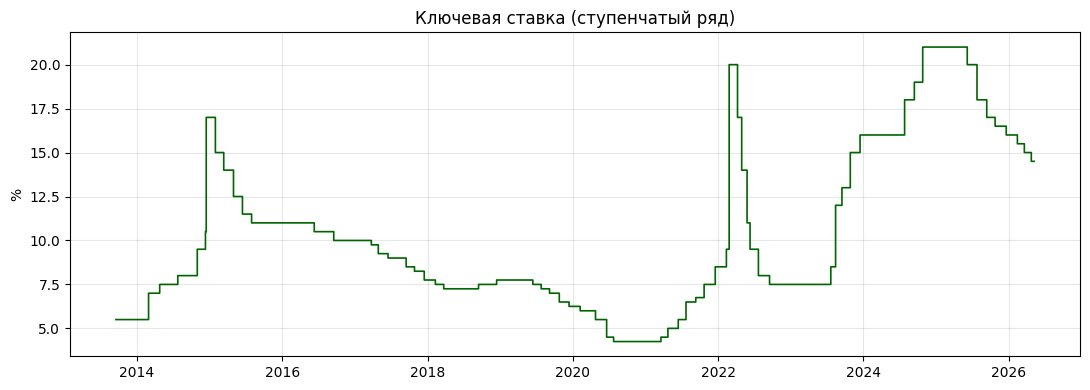

In [10]:
import matplotlib.pyplot as plt

print(df_keyrate["Ключевая_ставка"].describe())
print("\nИзменение ставки (абсолютный шаг, п.п.):")
chg = df_keyrate["Ключевая_ставка"].diff().dropna()
print(chg.describe())

fig, ax = plt.subplots(figsize=(11, 4))
ax.step(df_keyrate["Дата"], df_keyrate["Ключевая_ставка"], where="post", color="darkgreen", lw=1.2)
ax.set_title("Ключевая ставка (ступенчатый ряд)")
ax.set_ylabel("%")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Интерпретация: ключевая ставка ЦБ (M2)**

Ступенчатый график воспроизводит официальные уровни ставки между заседаниями: **горизонтальные плато** — периоды неизменной политики, **вертикальные скачки** — решения о повышении/снижении. Статистика по первым разностям (в п.п.) показывает типичный размер шага и наличие редких крупных изменений. Для последующего сравнения с репо важно, что это медленно меняющийся якорь: краткосрочные колебания рынка проявятся сильнее в спреде и покрытии, чем в самом этом ряду.

In [11]:

print("📁 Загружаем auctions_history_7d.csv...")
df_auctions = pd.read_csv('auctions_history_7d.csv')
df_auctions['Дата'] = pd.to_datetime(df_auctions['Дата'])

print(f"Загружено {len(df_auctions)} аукционов")
print(f"Период аукционов: с {df_auctions['Дата'].min().date()} по {df_auctions['Дата'].max().date()}")
print("\nПервые 5 строк аукционов:")
df_auctions.head()

📁 Загружаем auctions_history_7d.csv...
Загружено 244 аукционов
Период аукционов: с 2010-01-19 по 2026-05-05

Первые 5 строк аукционов:


,Дата,Спрос,Размещение,Средневзвешенная_ставка,Срок,Ставка_отсечения,Cover_ratio
0,2010-01-19,48845.3,48845.3,6.07,7,NaN,1.0
1,2010-01-26,86322.9,86322.9,6.15,7,NaN,1.0
2,2010-02-16,19622.5,19622.5,6.08,7,NaN,1.0
3,2010-03-02,48410.5,48410.5,5.86,7,NaN,1.0
4,2010-03-23,28105.0,28105.0,5.93,7,NaN,1.0


### EDA: репо 7 дней из `auctions_history_7d.csv`

Репозиторий аукционов: объёмы, покрытие спросом, ставки без привязки к ключевой (она ниже).

                         count          mean           std       min  \
Спрос                    244.0  1.910273e+06  1.398590e+06  674.0000   
Размещение               244.0  1.554622e+06  1.151283e+06  674.0000   
Средневзвешенная_ставка  244.0  1.119620e+01  4.942053e+00    5.0300   
Срок                     244.0  7.000000e+00  0.000000e+00    7.0000   
Ставка_отсечения         212.0  1.198383e+01  4.689123e+00    5.2501   
Cover_ratio              244.0  1.404912e+00  9.854845e-01    1.0000   

                                 25%           50%           75%           max  
Спрос                    801200.5500  1.865767e+06  2.567448e+06  6.937778e+06  
Размещение               582500.0000  1.485253e+06  2.367629e+06  4.610000e+06  
Средневзвешенная_ставка       5.9125  1.152265e+01  1.551570e+01  2.130710e+01  
Срок                          7.0000  7.000000e+00  7.000000e+00  7.000000e+00  
Ставка_отсечения              7.5500  1.160975e+01  1.567075e+01  2.126320e+01  
Cover_rat

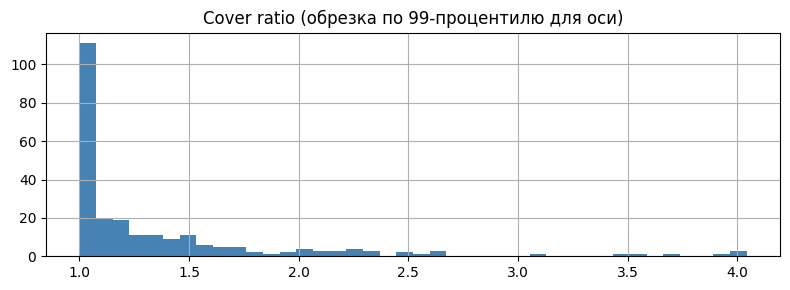

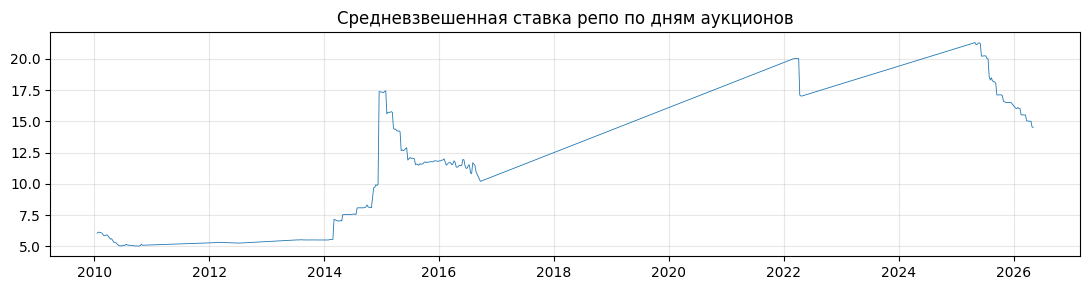

In [12]:
num_cols = [c for c in df_auctions.columns if c != "Дата" and pd.api.types.is_numeric_dtype(df_auctions[c])]
print(df_auctions[num_cols].describe().T)
print("\nПропуски:")
print(df_auctions[num_cols].isna().mean().mul(100).round(2))

if "Cover_ratio" in df_auctions.columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    df_auctions["Cover_ratio"].clip(upper=df_auctions["Cover_ratio"].quantile(0.99)).hist(bins=40, ax=ax, color="steelblue")
    ax.set_title("Cover ratio (обрезка по 99-процентилю для оси)")
    plt.tight_layout()
    plt.show()

if "Средневзвешенная_ставка" in df_auctions.columns:
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.plot(df_auctions["Дата"], df_auctions["Средневзвешенная_ставка"], lw=0.6)
    ax.set_title("Средневзвешенная ставка репо по дням аукционов")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

**Интерпретация: репо 7 дней (сырые аукционы) (M2)**

Гистограмма **Cover_ratio** с усечением по 99-му перцентилю подчёркивает основную массу наблюдений: если пик узкий умеренно выше 1, большинство аукционов сбалансированы; длинный правый хвост до обрезки соответствует редким дням с очень высоким спросом. Временной ряд **средневзвешенной ставки** по датам аукционов отражает эволюцию стоимости однонедельного фондирования между площадками ЦБ; его форма до объединения с ключевой ставкой уже показывает циклы ужесточения/смягчения ликвидности на горизонте репо.

In [13]:

print(" Объединяем аукционы с ключевой ставкой...")
df_final = df_auctions.merge(df_keyrate, on='Дата', how='left')


first_rate = df_keyrate['Ключевая_ставка'].iloc[0]
df_final['Ключевая_ставка'] = df_final['Ключевая_ставка'].fillna(first_rate)


df_final['Rate_spread'] = df_final['Средневзвешенная_ставка'] - df_final['Ключевая_ставка']


df_final['Flag_Demand'] = (df_final['Cover_ratio'] > 2.0).astype(int)

print(f" Объединено {len(df_final)} записей")
print(f"Аукционов с переспросом (Cover > 2.0): {df_final['Flag_Demand'].sum()}")

print("\nПервые 5 строк результата:")
df_final[['Дата', 'Cover_ratio', 'Средневзвешенная_ставка', 'Ключевая_ставка', 'Rate_spread', 'Flag_Demand']].head()

 Объединяем аукционы с ключевой ставкой...
 Объединено 244 записей
Аукционов с переспросом (Cover > 2.0): 31

Первые 5 строк результата:


,Дата,Cover_ratio,Средневзвешенная_ставка,Ключевая_ставка,Rate_spread,Flag_Demand
0,2010-01-19,1.0,6.07,14.5,-8.43,0
1,2010-01-26,1.0,6.15,14.5,-8.35,0
2,2010-02-16,1.0,6.08,14.5,-8.42,0
3,2010-03-02,1.0,5.86,14.5,-8.64,0
4,2010-03-23,1.0,5.93,14.5,-8.57,0


In [14]:
import pandas as pd

# 1. Загрузка аукционов
df_auctions = pd.read_csv('auctions_history_7d.csv')
df_auctions['Дата'] = pd.to_datetime(df_auctions['Дата'])


url_keyrate = "https://www.cbr.ru/hd_base/keyrate/?UniDbQuery.Posted=True&UniDbQuery.From=17.09.2013&UniDbQuery.To=08.05.2026"
tables = pd.read_html(url_keyrate)
df_keyrate = tables[0]
df_keyrate.columns = ['Дата', 'Ключевая_ставка']
df_keyrate['Дата'] = pd.to_datetime(df_keyrate['Дата'], format='%d.%m.%Y')
df_keyrate['Ключевая_ставка'] = df_keyrate['Ключевая_ставка'].astype(str).str.replace(',', '.').astype(float) / 100


print("="*60)
print("ОБРЕЗКА ДАННЫХ")
print("="*60)

print(f"До обрезки: {len(df_auctions)} аукционов")
print(f"Период: {df_auctions['Дата'].min().date()} - {df_auctions['Дата'].max().date()}")

# Оставляем только аукционы с 1 января 2013 года
df_auctions_clean = df_auctions[df_auctions['Дата'] >= '2013-01-01'].copy()

print(f"\nПосле обрезки: {len(df_auctions_clean)} аукционов")
print(f"Период: {df_auctions_clean['Дата'].min().date()} - {df_auctions_clean['Дата'].max().date()}")

# 4. Объединяем с ключевой ставкой
df_final = df_auctions_clean.merge(df_keyrate, on='Дата', how='inner')  # inner — только совпадающие даты

print(f"\nПосле объединения с ключевой ставкой: {len(df_final)} записей")

# 5. Рассчитываем спред
df_final['Rate_spread'] = df_final['Средневзвешенная_ставка'] - df_final['Ключевая_ставка']

# 6. Флаг переспроса
df_final['Flag_Demand'] = (df_final['Cover_ratio'] > 2.0).astype(int)

print("\n" + "="*60)
print("ИТОГОВАЯ ТАБЛИЦА (2013-2026)")
print("="*60)
print(f"Всего записей: {len(df_final)}")
print(f"Период: {df_final['Дата'].min().date()} - {df_final['Дата'].max().date()}")
print(f"Аукционов с переспросом: {df_final['Flag_Demand'].sum()}")

print("\nПервые 5 строк:")
display(df_final.head())

print("\nПоследние 5 строк:")
display(df_final.tail())

# Сохраняем
df_final.to_csv('auctions_2013_2026_with_keyrate.csv', index=False, encoding='utf-8-sig')
print("\n Файл 'auctions_2013_2026_with_keyrate.csv' сохранён!")

ОБРЕЗКА ДАННЫХ
До обрезки: 244 аукционов
Период: 2010-01-19 - 2026-05-05

После обрезки: 211 аукционов
Период: 2013-07-02 - 2026-05-05

После объединения с ключевой ставкой: 200 записей

ИТОГОВАЯ ТАБЛИЦА (2013-2026)
Всего записей: 200
Период: 2013-09-17 - 2026-05-05
Аукционов с переспросом: 30

Первые 5 строк:


,Дата,Спрос,Размещение,Средневзвешенная_ставка,Срок,Ставка_отсечения,Cover_ratio,Ключевая_ставка,Rate_spread,Flag_Demand
0,2013-09-17,2103063.9,2103063.9,5.5201,7,5.5,1.0,5.5,0.0201,0
1,2013-09-24,2055690.3,2055690.3,5.5198,7,5.5,1.0,5.5,0.0198,0
2,2013-10-01,2202936.0,2202936.0,5.5201,7,5.5,1.0,5.5,0.0201,0
3,2013-10-08,1786674.4,1786674.4,5.5194,7,5.5,1.0,5.5,0.0194,0
4,2013-10-15,1676722.9,1676722.9,5.5314,7,5.5,1.0,5.5,0.0314,0



Последние 5 строк:


,Дата,Спрос,Размещение,Средневзвешенная_ставка,Срок,Ставка_отсечения,Cover_ratio,Ключевая_ставка,Rate_spread,Flag_Demand
195,2026-04-07,6198663.5,4610000.0,15.0151,7,15.0015,1.344612,15.0,0.0151,0
196,2026-04-14,5225511.4,4330000.0,15.0130,7,15.0000,1.206816,15.0,0.0130,0
197,2026-04-21,5175118.1,4480000.0,15.0114,7,15.0000,1.155160,15.0,0.0114,0
198,2026-04-28,6937777.9,4590000.0,14.5494,7,14.5014,1.511498,14.5,0.0494,0
199,2026-05-05,5427593.6,4130000.0,14.5141,7,14.5014,1.314187,14.5,0.0141,0



 Файл 'auctions_2013_2026_with_keyrate.csv' сохранён!


### EDA: итог после объединения (2013+ и ключевая ставка)

`df_final` — аукционы согласованы с днями ключевой ставки; здесь распределения **`Cover_ratio`**, **`Rate_spread`** и доля **`Flag_Demand`**.

(200, 10) | период 2013-09-17 — 2026-05-05


,count,mean,std,min,25%,50%,75%,max
Спрос,200.0,2.225104e+06,1.304818e+06,138782.5000,1.317897e+06,2.114224e+06,2.712786e+06,6.937778e+06
Размещение,200.0,1.791456e+06,1.082835e+06,10000.0000,8.950000e+05,1.678361e+06,2.567448e+06,4.610000e+06
Средневзвешенная_ставка,200.0,1.248236e+01,4.536880e+00,5.5164,8.113225e+00,1.182425e+01,1.602760e+01,2.130710e+01
Срок,200.0,7.000000e+00,0.000000e+00,7.0000,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00
Ставка_отсечения,200.0,1.237411e+01,4.539716e+00,5.5000,8.046250e+00,1.170375e+01,1.600160e+01,2.126320e+01
Cover_ratio,200.0,1.488538e+00,1.068430e+00,1.0000,1.013144e+00,1.204509e+00,1.542484e+00,1.387825e+01
Ключевая_ставка,200.0,1.218500e+01,4.529166e+00,5.5000,8.000000e+00,1.100000e+01,1.600000e+01,2.100000e+01
Rate_spread,200.0,2.973555e-01,2.995128e-01,0.0011,4.562500e-02,1.669500e-01,5.107750e-01,1.195900e+00
Flag_Demand,200.0,1.500000e-01,3.579675e-01,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00



Доля переспроса (Cover > 2): 15.0 %


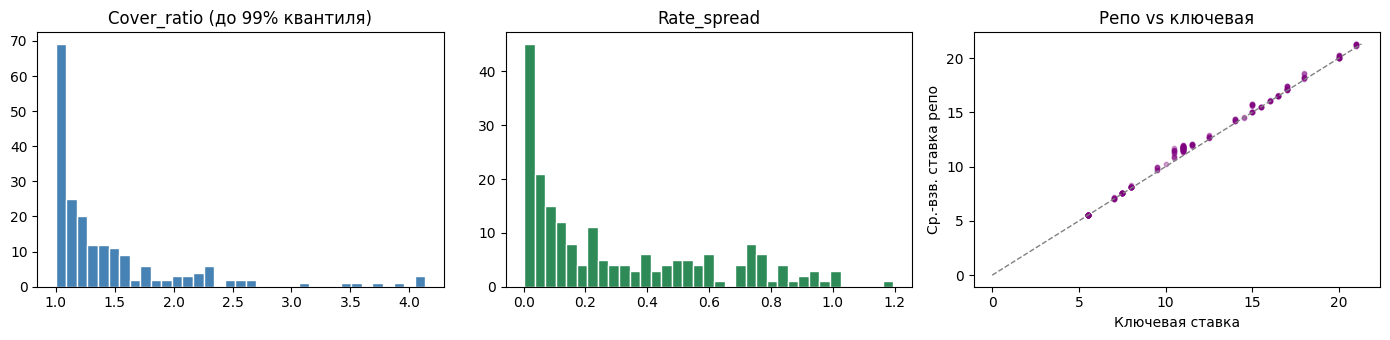

In [15]:
cols = ["Дата", "Cover_ratio", "Средневзвешенная_ставка", "Ключевая_ставка", "Rate_spread", "Flag_Demand"]
avail = [c for c in cols if c in df_final.columns]
print(df_final.shape, "| период", df_final["Дата"].min().date(), "—", df_final["Дата"].max().date())
num = [c for c in df_final.columns if c != "Дата" and pd.api.types.is_numeric_dtype(df_final[c])]
display(df_final[num].describe().T)

if "Flag_Demand" in df_final.columns:
    print("\nДоля переспроса (Cover > 2):", round(df_final["Flag_Demand"].mean() * 100, 2), "%")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
if "Cover_ratio" in df_final.columns:
    cr = df_final["Cover_ratio"].clip(upper=df_final["Cover_ratio"].quantile(0.99))
    axes[0].hist(cr, bins=35, color="steelblue", edgecolor="white")
    axes[0].set_title("Cover_ratio (до 99% квантиля)")
if "Rate_spread" in df_final.columns:
    axes[1].hist(df_final["Rate_spread"].dropna(), bins=35, color="seagreen", edgecolor="white")
    axes[1].set_title("Rate_spread")
if {"Средневзвешенная_ставка", "Ключевая_ставка"}.issubset(df_final.columns):
    axes[2].scatter(
        df_final["Ключевая_ставка"],
        df_final["Средневзвешенная_ставка"],
        s=10,
        alpha=0.35,
        c="purple",
    )
    mx = float(max(df_final["Ключевая_ставка"].max(), df_final["Средневзвешенная_ставка"].max()))
    axes[2].plot([0, mx], [0, mx], ls="--", color="gray", lw=1)
    axes[2].set_xlabel("Ключевая ставка")
    axes[2].set_ylabel("Ср.-взв. ставка репо")
    axes[2].set_title("Репо vs ключевая")
plt.tight_layout()
plt.show()

**Интерпретация: объединённый датасет аукционов и ключевой ставки (M2)**

**Гистограмма Cover_ratio** (до 99-го перцентиля) показывает, насколько типично аукцион переподписан или недоподписан: масса около 1–1.5 соответствует умеренному спросу, правый хвост — переспрос.

**Rate_spread** (репо минус ключевая) в распределении отвечает на вопрос, насколько дорого или дёшево банки финансируются относительно «якорной» ставки ЦБ в дни размещений; смещение в сторону положительных значений означает премию к ключевой.

**Диаграмма рассеяния «ключевая vs средневзвешенная репо»** с линией 45°: точки **выше** диагонали — ставка репо выше ключевой (жёстче условия фондирования в этот день), **ниже** — мягче. Облако вдоль диагонали говорит о согласованности двух рядов; систематический разрыв — о структурной премии или дисконте репо.

In [16]:
# Рассчитываем MAD_score для Cover_ratio и Rate_spread
def calc_mad_score(df, column, window_days=1095):  # 1095 дней = 3 года
    scores = []
    for i in range(len(df)):
        current_date = df['Дата'].iloc[i]
        start_date = current_date - pd.Timedelta(days=window_days)

        # Данные за последние 3 года (без текущего)
        mask = (df['Дата'] >= start_date) & (df['Дата'] < current_date)
        window_data = df.loc[mask, column]

        if len(window_data) >= 10:
            median_val = window_data.median()
            mad_val = (window_data - median_val).abs().median()
            if mad_val > 0:
                score = (df[column].iloc[i] - median_val) / mad_val
            else:
                score = 0.0
        else:
            score = 0.0
        scores.append(score)
    return scores

df_final['MAD_score_cover'] = calc_mad_score(df_final, 'Cover_ratio')
df_final['MAD_score_rate_spread'] = calc_mad_score(df_final, 'Rate_spread')

print("MAD-нормализация выполнена!")
print(f"MAD_score_cover: от {df_final['MAD_score_cover'].min():.2f} до {df_final['MAD_score_cover'].max():.2f}")
print(f"MAD_score_rate_spread: от {df_final['MAD_score_rate_spread'].min():.2f} до {df_final['MAD_score_rate_spread'].max():.2f}")

MAD-нормализация выполнена!
MAD_score_cover: от -12.79 до 113.79
MAD_score_rate_spread: от -8.78 до 78.83


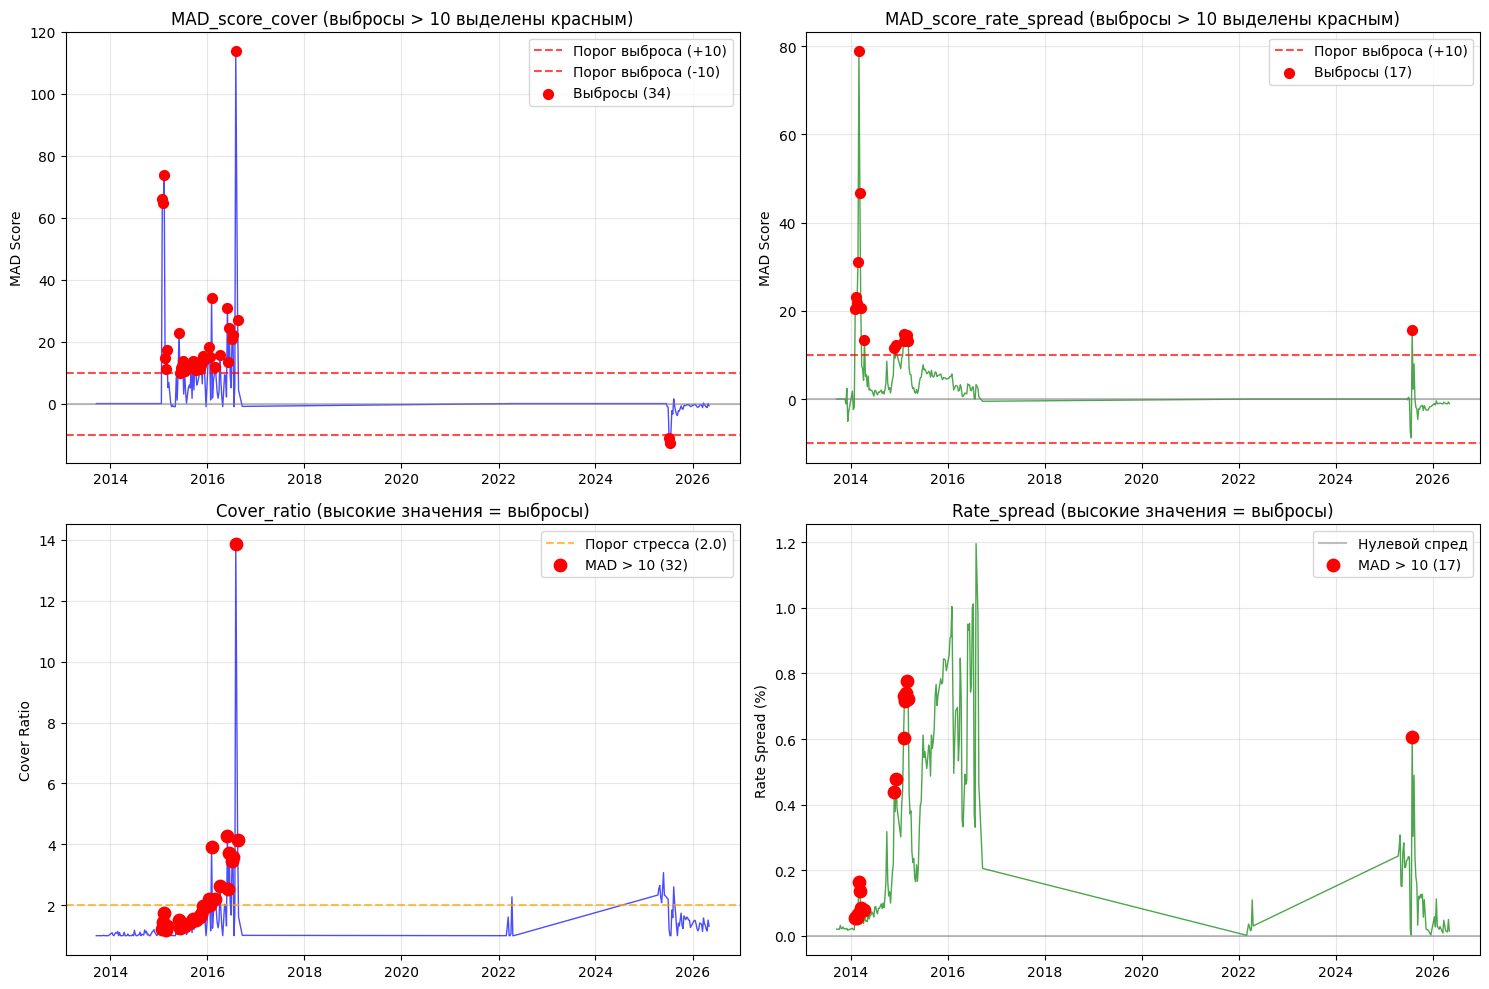

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# График 1: MAD_score_cover с порогами
ax1 = axes[0, 0]
ax1.plot(df_final['Дата'], df_final['MAD_score_cover'], 'b-', linewidth=1, alpha=0.7)
ax1.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Порог выброса (+10)')
ax1.axhline(y=-10, color='red', linestyle='--', alpha=0.7, label='Порог выброса (-10)')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax1.set_title('MAD_score_cover (выбросы > 10 выделены красным)')
ax1.set_ylabel('MAD Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Выделяем выбросы на графике
outliers_cover = df_final[df_final['MAD_score_cover'].abs() > 10]
ax1.scatter(outliers_cover['Дата'], outliers_cover['MAD_score_cover'],
           color='red', s=50, zorder=5, label=f'Выбросы ({len(outliers_cover)})')
ax1.legend()

# График 2: MAD_score_rate_spread с порогами
ax2 = axes[0, 1]
ax2.plot(df_final['Дата'], df_final['MAD_score_rate_spread'], 'g-', linewidth=1, alpha=0.7)
ax2.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Порог выброса (+10)')
ax2.axhline(y=-10, color='red', linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_title('MAD_score_rate_spread (выбросы > 10 выделены красным)')
ax2.set_ylabel('MAD Score')
ax2.legend()
ax2.grid(True, alpha=0.3)

outliers_spread = df_final[df_final['MAD_score_rate_spread'].abs() > 10]
ax2.scatter(outliers_spread['Дата'], outliers_spread['MAD_score_rate_spread'],
           color='red', s=50, zorder=5, label=f'Выбросы ({len(outliers_spread)})')
ax2.legend()

# График 3: Cover_ratio с выделением выбросов
ax3 = axes[1, 0]
ax3.plot(df_final['Дата'], df_final['Cover_ratio'], 'b-', linewidth=1, alpha=0.7)
ax3.axhline(y=2.0, color='orange', linestyle='--', alpha=0.7, label='Порог стресса (2.0)')
ax3.set_title('Cover_ratio (высокие значения = выбросы)')
ax3.set_ylabel('Cover Ratio')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Выделяем точки с высоким MAD_score
high_mad_cover = df_final[df_final['MAD_score_cover'] > 10]
ax3.scatter(high_mad_cover['Дата'], high_mad_cover['Cover_ratio'],
           color='red', s=80, zorder=5, label=f'MAD > 10 ({len(high_mad_cover)})')
ax3.legend()

# График 4: Rate_spread с выделением выбросов
ax4 = axes[1, 1]
ax4.plot(df_final['Дата'], df_final['Rate_spread'], 'g-', linewidth=1, alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle='-', alpha=0.5, label='Нулевой спред')
ax4.set_title('Rate_spread (высокие значения = выбросы)')
ax4.set_ylabel('Rate Spread (%)')
ax4.legend()
ax4.grid(True, alpha=0.3)

high_mad_spread = df_final[df_final['MAD_score_rate_spread'] > 10]
ax4.scatter(high_mad_spread['Дата'], high_mad_spread['Rate_spread'],
           color='red', s=80, zorder=5, label=f'MAD > 10 ({len(high_mad_spread)})')
ax4.legend()

plt.tight_layout()
plt.show()

**Интерпретация: MAD и исходные ряды после объединения (M2)**

Четыре подграфика связывают робастную нормализацию с «сырыми» метриками. Ряды **MAD_score_cover** и **MAD_score_rate_spread** вокруг нуля показывают типичные колебания; выбросы за пороги ±10 — дни, когда текущее значение сильно отличается от медианы окна из трёх лет. Красные точки на нижних панелях (**Cover_ratio**, **Rate_spread**) отмечают те же даты: это эпизоды экстремального спроса на аукционе или аномального спреда ставки репо к ключевой. Совпадение всплесков на верхнем и нижнем ряду подтверждает, что MAD действительно ловит экономически значимые хвосты, а не только артефакты.